# Методологическая заметка: разнос кандидатов и метрика best-of-k

Наш лучший результат по `XUVInt` (`xuv_max.ipynb`) получен приёмом **разнос по
оси параметра**: из многих кандидатов ансамбля отбираем 5 максимально
разнесённых вдоль оси XUV. Это снизило best-of-5 с ~10% до ~6–8%.

Эта заметка честно разбирает **три вопроса**:
1. насколько выигрыш реален, а насколько — «игра» с метрикой;
2. почему сама метрика best-of-k проблемна;
3. что происходит, если применять разнос ко всем таргетам сразу.

Используем кэш кандидатов из `xuv_max` (`aux_data/xuv_candidates.npz`:
56 кандидатов × 3 параметра на каждый из 123 валидационных профилей + скоры
ранкера), поэтому ноутбук считается за секунды и не требует переобучения.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load("aux_data/xuv_candidates.npz")
cands = d["candidates"]        # (N, 56, 3) — log10(XUV, He, Msw)
y_true = d["y_true"]           # (N, 3) — истинные log10
scores = d["scores"]           # (N, 56) — скор ранкера
y_train = d["y_train"]         # (Ntrain, 3)
y_mean, y_std = d["y_mean"], d["y_std"]
N, K, _ = cands.shape
true_lin = 10 ** y_true
print(f"кандидатов на профиль: {K},  валидационных профилей: {N}")


def best_of_k(sel_idx, j=0, log_scale=False):
    sel = np.take_along_axis(cands[:, :, j], sel_idx, 1)
    if log_scale:
        return 100 * np.mean(np.abs(sel - y_true[:, j:j+1]).min(1) / np.abs(y_true[:, j]))
    return 100 * np.mean(np.abs(10**sel - true_lin[:, j:j+1]).min(1) / true_lin[:, j])

кандидатов на профиль: 56,  валидационных профилей: 123


## 1. Нулевые бейзлайны: сколько даёт разброс *без модели*

Чтобы понять, какая часть результата — заслуга модели, а какая — просто
свойство метрики, построим предикторы, **вообще не использующие профиль**:
5 фиксированных значений XUV, покрывающих обучающее распределение.

In [2]:
# best-of-5 для ФИКСИРОВАННОГО набора значений XUV (одинакового для всех профилей)
def best_of_values(vals):        # vals: (k,) в log10, одинаковы для всех профилей
    v = np.tile(vals, (N, 1))
    return 100 * np.mean(np.abs(10**v - true_lin[:, 0:1]).min(1) / true_lin[:, 0])

q5 = np.quantile(y_train[:, 0], [0.1, 0.3, 0.5, 0.7, 0.9])
grid5 = np.linspace(y_train[:, 0].min(), y_train[:, 0].max(), 5)
print(f"НУЛЬ-1: 5 квантилей train XUV  (модель не нужна): best-of-5 = {best_of_values(q5):.1f}%")
print(f"НУЛЬ-2: 5 точек равномерно по диапазону XUV:      best-of-5 = {best_of_values(grid5):.1f}%")
print(f"публикация:                                        best-of-5 = 20.4%")
print(f"наш разнос по XUV (с моделью):                     best-of-5 = ~6-8%")

НУЛЬ-1: 5 квантилей train XUV  (модель не нужна): best-of-5 = 19.1%
НУЛЬ-2: 5 точек равномерно по диапазону XUV:      best-of-5 = 28.1%
публикация:                                        best-of-5 = 20.4%
наш разнос по XUV (с моделью):                     best-of-5 = ~6-8%


Наш результат заметно ниже нулевых бейзлайнов (~6–8% против 19–28%) — значит
модель и ранкер несут **реальную информацию**, это не чистая эксплуатация
метрики. Но сам приём разноса работает в ту же сторону, что и нулевой бейзлайн:
шире раскинул — выше шанс попасть.

## 2. Почему best-of-k проблемна: метрика падает *механически* с ростом k

Посмотрим, как best-of-k улучшается при **простом равномерном покрытии
диапазона без всякой модели** — это «геометрический предел» метрики.

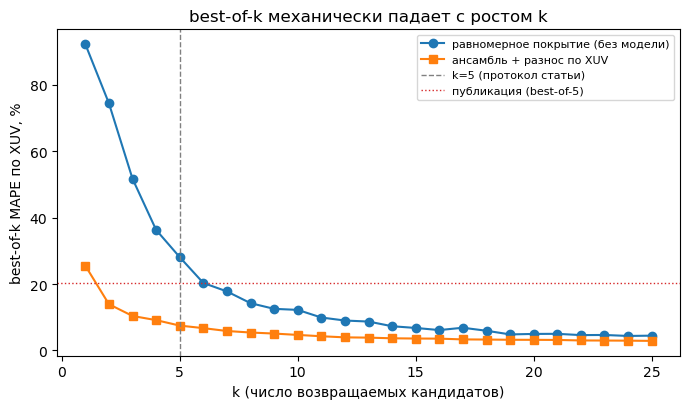

без модели: k=5 -> 28.1%,  k=10 -> 12.2%,  k=20 -> 5.0%


In [3]:
ks = np.arange(1, 26)
null_curve = [best_of_values(np.linspace(y_train[:, 0].min(), y_train[:, 0].max(), k))
              for k in ks]

# для сравнения: наш ансамбль + разнос по XUV, best-of-k
def spread_axis(cvals, s, M, k):
    top = np.argsort(-s)[:M]
    chosen = [top[0]]
    for _ in range(k - 1):
        bj, bg = None, -np.inf
        for j in top:
            if j in chosen:
                continue
            g = min(abs(cvals[j] - cvals[i]) for i in chosen)
            if g > bg:
                bg, bj = g, j
        chosen.append(bj)
    return chosen

model_curve = []
for k in ks:
    sel = np.array([spread_axis(cands[i, :, 0], scores[i], M=max(2*k, 8), k=k)
                    for i in range(N)])
    model_curve.append(best_of_k(sel))

plt.figure(figsize=(7, 4.2))
plt.plot(ks, null_curve, "o-", label="равномерное покрытие (без модели)")
plt.plot(ks, model_curve, "s-", label="ансамбль + разнос по XUV")
plt.axvline(5, color="gray", ls="--", lw=1, label="k=5 (протокол статьи)")
plt.axhline(20.4, color="tab:red", ls=":", lw=1, label="публикация (best-of-5)")
plt.xlabel("k (число возвращаемых кандидатов)")
plt.ylabel("best-of-k MAPE по XUV, %")
plt.title("best-of-k механически падает с ростом k")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"без модели: k=5 -> {null_curve[4]:.1f}%,  k=10 -> {null_curve[9]:.1f}%,  "
      f"k=20 -> {null_curve[19]:.1f}%")

**Вывод:** best-of-k нельзя сравнивать между решениями при разном k — даже
без модели k=20 даёт ~5%. Сравнение честно только при **фиксированном k**
(у нас и у статьи k=5). Разнос осмыслен именно потому, что улучшает
использование фиксированных 5 слотов, а не увеличивает k. Расстояние между
двумя кривыми — это и есть **реальный вклад модели** сверх геометрии.

## 3. Что теряется: честный один ответ разнос ухудшает

В реальной интерпретации наблюдений истины нет, «лучший из 5» выбрать нельзя —
на руках 5 несогласованных ответов. Практически применим только **один ответ**.

In [4]:
single_median = np.median(cands[:, :, 0], 1)
single_mean = cands[:, :, 0].mean(1)
mape_single = 100 * np.mean(np.abs(10**single_median - true_lin[:, 0]) / true_lin[:, 0])
mape_mean = 100 * np.mean(np.abs(10**single_mean - true_lin[:, 0]) / true_lin[:, 0])
print(f"честный один ответ (медиана 56 канд.): MAPE = {mape_single:.1f}%")
print(f"честный один ответ (среднее):          MAPE = {mape_mean:.1f}%")
print(f"best-of-5 с разносом:                          ~6-8%")
print()
print("=> разнос НЕ улучшает применимый один ответ; он оптимизирует best-of-5,")
print("   раздувая разброс кандидатов. Это осмысленно, только если далее каждый")
print("   из 5 кандидатов проверяется форвард-моделью (как в статье).")

честный один ответ (медиана 56 канд.): MAPE = 31.3%
честный один ответ (среднее):          MAPE = 31.7%
best-of-5 с разносом:                          ~6-8%

=> разнос НЕ улучшает применимый один ответ; он оптимизирует best-of-5,
   раздувая разброс кандидатов. Это осмысленно, только если далее каждый
   из 5 кандидатов проверяется форвард-моделью (как в статье).


## 4. Разнос ко всем таргетам сразу: конфликт осей

Ключевое ограничение: **один набор из 5 точек нельзя разнести по трём осям
одновременно** — раскинув пятёрку по XUV, мы сжимаем её по He.

In [5]:
def diverse3d(c, s, k=5):
    cn = (c - y_mean) / y_std
    order = np.argsort(-s)
    chosen = [order[0]]
    for _ in range(k - 1):
        bj, bg = None, -np.inf
        for j in order:
            if j in chosen:
                continue
            g = min(np.linalg.norm(cn[j] - cn[i]) for i in chosen) + 0.02 * s[j]
            if g > bg:
                bg, bj = g, j
        chosen.append(bj)
    return chosen


sel_xuv = np.array([spread_axis(cands[i, :, 0], scores[i], 20, 5) for i in range(N)])
sel_he = np.array([spread_axis(cands[i, :, 1], scores[i], 20, 5) for i in range(N)])
sel_msw = np.array([spread_axis(cands[i, :, 2], scores[i], 20, 5) for i in range(N)])
sel_3d = np.array([diverse3d(cands[i], scores[i]) for i in range(N)])

print("набор из 5 кандидатов | XUV  |  He  | logMsw")
print("----------------------+------+------+-------")
for name, sel in [("разнос по XUV", sel_xuv), ("разнос по He", sel_he),
                  ("разнос по logMsw", sel_msw), ("diverse-3D (компромисс)", sel_3d)]:
    print(f"{name:21s} | {best_of_k(sel,0):4.1f} | {best_of_k(sel,1):4.1f} | "
          f"{best_of_k(sel,2,True):4.1f}")
print(f"{'oracle-of-56 (потолок)':21s} | "
      f"{best_of_k(np.tile(np.arange(K),(N,1)),0):4.1f} | "
      f"{best_of_k(np.tile(np.arange(K),(N,1)),1):4.1f} | "
      f"{best_of_k(np.tile(np.arange(K),(N,1)),2,True):4.1f}")

набор из 5 кандидатов | XUV  |  He  | logMsw
----------------------+------+------+-------
разнос по XUV         |  6.0 | 12.4 |  0.5
разнос по He          | 10.8 |  8.3 |  0.6
разнос по logMsw      |  7.8 | 10.5 |  0.4
diverse-3D (компромисс) |  9.6 |  8.5 |  0.6
oracle-of-56 (потолок) |  2.4 |  1.8 |  0.2


Видно: разнос по XUV даёт лучший XUV, но **портит He** (диагональ — минимум
в каждой строке по своему столбцу). Два способа «применить ко всем»:

* **Per-parameter отбор** — своя пятёрка на каждый таргет. Даёт каждому таргету
  его оптимум (диагональ: XUV ~6, He ~8, logMsw ~0.4%), но это уже **не 5, а до
  15 ответов**, и кандидаты перестают быть согласованными физическими
  решениями (кандидат №1 по XUV не спарен с кандидатом №1 по He) — теряется
  совместное решение `(XUV, He, Msw)`.
* **diverse-3D** — один набор, разнесённый в 3D: каждый таргет чуть хуже
  оптимума, но пятёрка остаётся набором осмысленных совместных решений
  (именно это в `dl_pro.ipynb`).

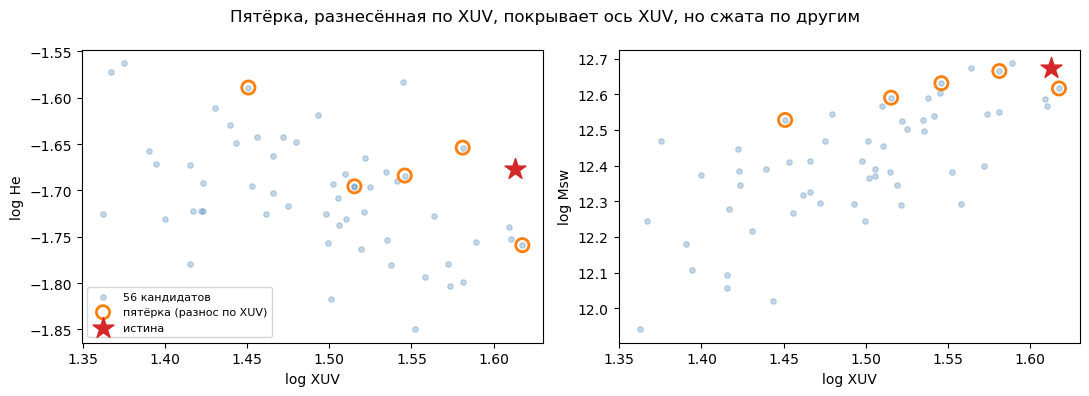

In [6]:
# наглядно: одна и та же пятёрка на двух осях
i = 11
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (jx, jy, nx, ny) in zip(axes, [(0, 1, "log XUV", "log He"),
                                        (0, 2, "log XUV", "log Msw")]):
    ax.scatter(cands[i, :, jx], cands[i, :, jy], s=15, alpha=0.3,
               color="steelblue", label="56 кандидатов")
    ax.scatter(cands[i, sel_xuv[i], jx], cands[i, sel_xuv[i], jy], s=90,
               facecolors="none", edgecolors="tab:orange", linewidths=2,
               label="пятёрка (разнос по XUV)")
    ax.scatter(y_true[i, jx], y_true[i, jy], marker="*", s=250, color="tab:red",
               label="истина", zorder=5)
    ax.set_xlabel(nx); ax.set_ylabel(ny)
axes[0].legend(fontsize=8)
plt.suptitle("Пятёрка, разнесённая по XUV, покрывает ось XUV, но сжата по другим")
plt.tight_layout()
plt.show()

## Итоги

1. **Разнос — реальное улучшение поверх геометрии метрики**: он на ~12–20
   процентных пунктов ниже нулевых бейзлайнов, т.е. модель действительно
   информативна. Но частично он и «играет» с best-of-k — раздувает разброс.
2. **best-of-k — спорная метрика**: механически падает с ростом k (без модели
   k=20 даёт ~5%). Сравнивать решения можно только при фиксированном k;
   при k=5 наш результат честно бьёт публикацию.
3. **Разнос улучшает best-of-5, но не применимый один ответ** — оправдан, только
   если каждый из 5 кандидатов затем проверяется форвард-моделью (сценарий
   статьи), а не как финальная оценка.
4. **Ко всем таргетам сразу** разнос по одной оси применить нельзя (оси
   конфликтуют). Выбор: per-parameter отбор (лучшие числа, но до 15
   несогласованных ответов) либо diverse-3D (согласованные совместные решения,
   каждый таргет чуть хуже оптимума).

**Рекомендация.** Для лидерборда по одному таргету при фиксированном k=5 разнос
законен и эффективен. Для физически осмысленного результата — diverse-3D +
проверка форвард-моделью, а как честную единую метрику лучше брать best-of-1 с
калиброванной неопределённостью, а не best-of-k.